In [1]:


import os, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

print("All libraries were successfully imported")

All libraries were successfully imported


In [2]:
DATA_DIR   = r"C:\Users\A0100\OneDrive\Desktop\sentiment analysis"
OUTPUT_DIR = r"C:\Users\A0100\OneDrive\Desktop\sentiment analysis\outputs"


os.makedirs(OUTPUT_DIR, exist_ok=True)


PALETTE = {
    "Positive": "#2ecc71",   
    "Neutral" : "#f39c12",   
    "Negative": "#e74c3c"    
}

DARK_BG = "#0f1117"  


plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor"  : "#1a1d27",
    "axes.edgecolor"  : "#2c2f3e",
    "grid.color"      : "#2c2f3e",
    "text.color"      : "#e0e0e0",
    "axes.labelcolor" : "#e0e0e0",
    "xtick.color"     : "#c0c0c0",
    "ytick.color"     : "#c0c0c0",
    "font.family"     : "DejaVu Sans",
    "font.size"       : 11,
})

print(f" مجلد الداتا  : {DATA_DIR}")
print(f" مجلد الـ Output: {OUTPUT_DIR}")

 مجلد الداتا  : C:\Users\A0100\OneDrive\Desktop\sentiment analysis
 مجلد الـ Output: C:\Users\A0100\OneDrive\Desktop\sentiment analysis\outputs


In [3]:
print("Loading data")

reviews   = pd.read_csv(os.path.join(DATA_DIR, "reviews_temp.csv"))
products  = pd.read_csv(os.path.join(DATA_DIR, "products_temp.csv"))
customers = pd.read_csv(os.path.join(DATA_DIR, "customers_temp.csv"))
orders    = pd.read_csv(os.path.join(DATA_DIR, "orders_temp.csv"))

print(f"    reviews  : {reviews.shape[0]} صف × {reviews.shape[1]} عمود")
print(f"    products : {products.shape[0]} صف × {products.shape[1]} عمود")
print(f"    customers: {customers.shape[0]} صف × {customers.shape[1]} عمود")
print(f"    orders   : {orders.shape[0]} صف × {orders.shape[1]} عمود")

Loading data
    reviews  : 4000 صف × 8 عمود
    products : 1000 صف × 10 عمود
    customers: 500 صف × 9 عمود
    orders   : 2000 صف × 8 عمود


In [4]:
print("First 5 reviews")
reviews.head()

First 5 reviews


,review_id,product_id,customer_id,review_text,star_rating,review_date,helpful_votes,verified_purchase
0,1,1,197,About 'A Light in the Attic' - Fair price for ...,3,2025-04-16,12,True
1,2,1,175,One of the worst books I've read this year. Sa...,2,2025-03-30,50,False
2,3,1,153,One of the worst books I've read this year. Sa...,2,2025-02-24,37,False
3,4,2,248,I regret buying this. The story is unoriginal ...,1,2025-03-21,22,False
4,5,2,194,I wanted to like this book but it was just too...,2,2024-06-12,29,False


In [5]:
print("Text cleaning in progress")

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()                                          
    text = re.sub(r"http\S+|www\S+", "", text)                   
    text = re.sub(r"[^a-z\s']", " ", text)                       
    text = re.sub(r"\s+", " ", text).strip()                     
    
    tokens = text.split()
    
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    
    return " ".join(tokens)


reviews["clean_text"] = reviews["review_text"].apply(clean_text)


reviews["review_date"] = pd.to_datetime(reviews["review_date"])
reviews["month_year"]  = reviews["review_date"].dt.to_period("M")

print("Texts have been cleaned!")
print("\n Example — Before and after completion:")
print(f"   Before: {reviews['review_text'].iloc[0][:100]}")
print(f"   After: {reviews['clean_text'].iloc[0][:100]}")

Text cleaning in progress
Texts have been cleaned!

 Example — Before and after completion:
   Before: About 'A Light in the Attic' - Fair price for an average book. The content is standard for this cate
   After: light attic' fair price average book content standard category


In [6]:
print("Vader is running")


sid = SentimentIntensityAnalyzer()

def vader_label(text):
    """بتحدد السنتيمنت بناءً على الـ Compound Score"""
    score = sid.polarity_scores(str(text))["compound"]
    if score >= 0.05:   return "Positive"
    if score <= -0.05:  return "Negative"
    return "Neutral"

def vader_score(text):
    """بترجع الـ Compound Score كرقم"""
    return sid.polarity_scores(str(text))["compound"]


reviews["vader_compound"] = reviews["review_text"].apply(vader_score)
reviews["vader_label"]    = reviews["review_text"].apply(vader_label)

print("VADER has been analyzed")
print("\n Distribution of the sentiment:")
print(reviews["vader_label"].value_counts())

Vader is running
VADER has been analyzed

 Distribution of the sentiment:
vader_label
Positive    2024
Negative    1604
Neutral      372
Name: count, dtype: int64


In [7]:
print("TextBlob is running")

def tb_polarity(text):
    """درجة الإيجابية/السلبية من -1 لـ +1"""
    return TextBlob(str(text)).sentiment.polarity

def tb_subjectivity(text):
    """درجة الذاتية: 0 = موضوعي، 1 = شخصي جداً"""
    return TextBlob(str(text)).sentiment.subjectivity

def tb_label(text):
    """تحديد التصنيف بنفس منطق VADER"""
    p = TextBlob(str(text)).sentiment.polarity
    if p > 0.05:   return "Positive"
    if p < -0.05:  return "Negative"
    return "Neutral"

reviews["tb_polarity"]     = reviews["review_text"].apply(tb_polarity)
reviews["tb_subjectivity"] = reviews["review_text"].apply(tb_subjectivity)
reviews["tb_label"]        = reviews["review_text"].apply(tb_label)


def star_label(rating):
    if rating >= 4:  return "Positive"
    if rating == 3:  return "Neutral"
    return "Negative"

reviews["star_label"] = reviews["star_rating"].apply(star_label)

print("TextBlob has been analyzed")
print(f"\n متوسط الـ Polarity  : {reviews['tb_polarity'].mean():.3f}")
print(f" متوسط الـ Subjectivity: {reviews['tb_subjectivity'].mean():.3f}")

TextBlob is running
TextBlob has been analyzed

 متوسط الـ Polarity  : 0.146
 متوسط الـ Subjectivity: 0.598


In [8]:
print("Emotions are still being explored")

EMOTION_LEXICON = {
    "joy"         : ["happy","love","wonderful","excellent","amazing","great","fantastic",
                     "enjoy","delight","pleased","thrilled","joy","awesome","best",
                     "perfect","incredible","glad","superb"],
    "anger"       : ["angry","furious","terrible","awful","horrible","hate","worst",
                     "disgusting","frustrated","outraged","mad","rage","annoyed",
                     "irritated","deplorable"],
    "fear"        : ["scared","afraid","worried","terrified","anxious","concerned",
                     "dread","fearful","panic","nervous"],
    "sadness"     : ["sad","disappointed","unhappy","regret","sorry","depressed",
                     "miserable","unfortunate","bad","awful","poor","waste","useless","boring"],
    "surprise"    : ["surprised","unexpected","shocking","amazed","astonishing",
                     "wow","unbelievable","incredible","sudden"],
    "trust"       : ["reliable","trustworthy","honest","genuine","authentic","quality",
                     "safe","dependable","recommend","consistent","professional"],
    "anticipation": ["looking forward","excited","eager","hopeful","expect","hope","wish","await"],
    "disgust"     : ["disgusting","gross","revolting","offensive","nauseating",
                     "horrible","repulsive","vile"],
}

def detect_emotions(text):
    """بتعد كم مرة ظهرت كلمات كل مشعر في النص"""
    text_l = str(text).lower()
    scores = {}
    for emotion, keywords in EMOTION_LEXICON.items():
        scores[emotion] = sum(1 for kw in keywords if kw in text_l)
    return scores


emotion_df = reviews["review_text"].apply(detect_emotions).apply(pd.Series)
reviews = pd.concat([reviews, emotion_df], axis=1)

def dominant_emotion(row):
    """بتحدد المشعر الأكثر ظهوراً في المراجعة"""
    emotions = {e: row[e] for e in EMOTION_LEXICON}
    top = max(emotions, key=emotions.get)
    return top if emotions[top] > 0 else "none"   

reviews["dominant_emotion"] = reviews.apply(dominant_emotion, axis=1)

print("Feelings have been detected")
print("\n The most common emotions:")
print(reviews["dominant_emotion"].value_counts())

Emotions are still being explored
Feelings have been detected

 The most common emotions:
dominant_emotion
none            1327
joy             1221
sadness          820
anger            363
trust            221
anticipation      45
fear               3
Name: count, dtype: int64


In [ ]:
print("Training the ML model is underway")


df_ml = reviews[reviews["clean_text"].str.len() > 5].copy()

X = df_ml["clean_text"]   
y = df_ml["star_label"]   


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      
    random_state=42,   
    stratify=y          
)


tfidf = TfidfVectorizer(
    max_features=5000,    
    ngram_range=(1, 2)    
)
X_train_v = tfidf.fit_transform(X_train)   
X_test_v  = tfidf.transform(X_test)        

# 3. Logistic Regression 
lr = LogisticRegression(
    max_iter=500,
    class_weight="balanced",  
    random_state=42
)
lr.fit(X_train_v, y_train)
y_pred = lr.predict(X_test_v)


reviews.loc[df_ml.index, "ml_label"] = lr.predict(tfidf.transform(X))

print("The model has been trained")
print("\n Performance report(Classification Report):")
print(classification_report(y_test, y_pred))

Training the ML model is underway
The model has been trained

 Performance report(Classification Report):
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       343
     Neutral       1.00      1.00      1.00       157
    Positive       1.00      1.00      1.00       300

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



In [10]:

df = reviews.merge(
        products[["product_id", "title", "category_id", "price"]],
        on="product_id",
        how="left"  
     ).merge(
        customers[["customer_id", "gender", "age", "country"]],
        on="customer_id",
        how="left"
     )

print(f"✅ Merging completed! The final table: {df.shape[0]} row × {df.shape[1]} column")
df.head(3)

✅ Merging completed! The final table: 4000 row × 32 column


,review_id,product_id,customer_id,review_text,star_rating,review_date,helpful_votes,verified_purchase,clean_text,month_year,...,anticipation,disgust,dominant_emotion,ml_label,title,category_id,price,gender,age,country
0,1,1,197,About 'A Light in the Attic' - Fair price for ...,3,2025-04-16,12,True,light attic' fair price average book content s...,2025-04,...,0,0,anger,Neutral,A Light in the Attic,22.0,51.77,Male,52,Kyrgyz Republic
1,2,1,175,One of the worst books I've read this year. Sa...,2,2025-03-30,50,False,one worst book read year save money buy someth...,2025-03,...,0,0,anger,Negative,A Light in the Attic,22.0,51.77,Female,57,New Zealand
2,3,1,153,One of the worst books I've read this year. Sa...,2,2025-02-24,37,False,one worst book read year save money buy someth...,2025-02,...,0,0,anger,Negative,A Light in the Attic,22.0,51.77,Male,61,Timor-Leste


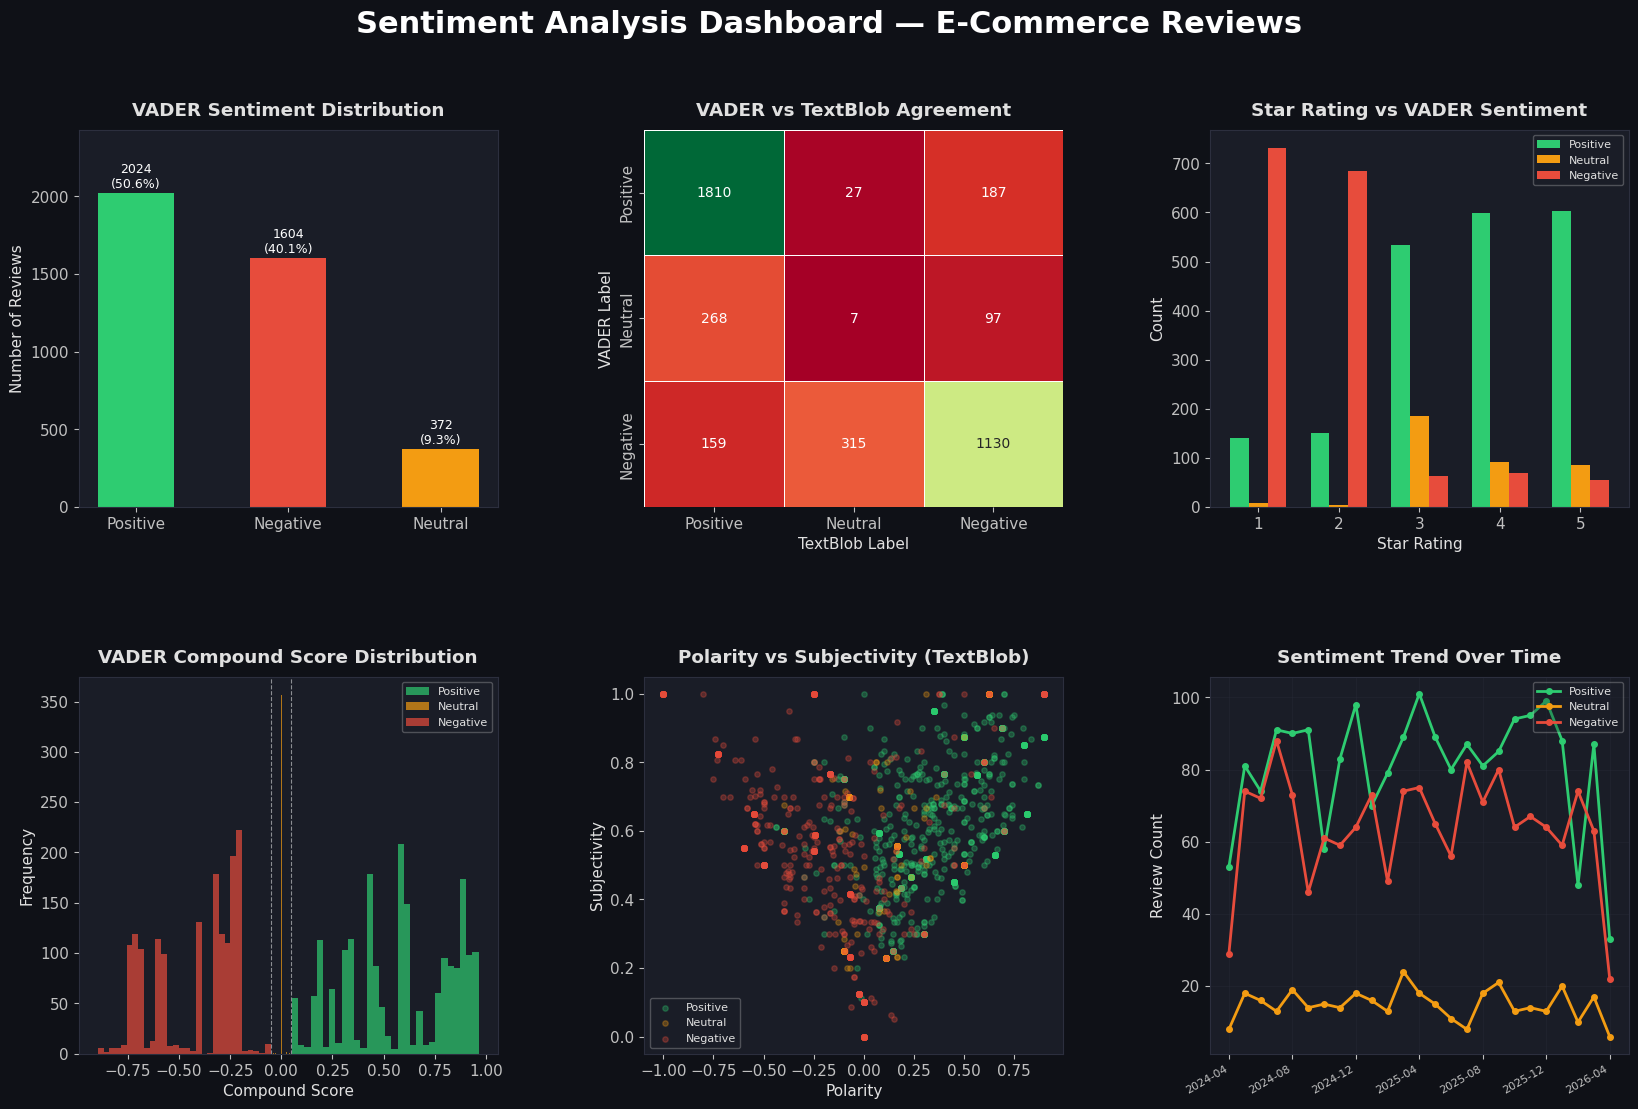

01:saved_overview_dashboard.png


In [11]:
fig = plt.figure(figsize=(20, 12), facecolor=DARK_BG)
fig.suptitle("Sentiment Analysis Dashboard — E-Commerce Reviews",
             fontsize=22, fontweight="bold", color="white", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# (a) VADER sentiment disttribution
ax1 = fig.add_subplot(gs[0, 0])
counts = reviews["vader_label"].value_counts()
bars = ax1.bar(counts.index, counts.values,
               color=[PALETTE[l] for l in counts.index], width=0.5, edgecolor="none")
for bar, v in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             f"{v}\n({v/len(reviews)*100:.1f}%)",
             ha="center", va="bottom", fontsize=9, color="white")
ax1.set_title("VADER Sentiment Distribution", fontweight="bold", pad=10)
ax1.set_ylabel("Number of Reviews")
ax1.set_ylim(0, counts.max() * 1.2)

# (b) VADER vs TextBlob (Heatmap) 
ax2 = fig.add_subplot(gs[0, 1])
compare = pd.crosstab(reviews["vader_label"], reviews["tb_label"])
compare = compare.reindex(index=["Positive","Neutral","Negative"],
                           columns=["Positive","Neutral","Negative"], fill_value=0)
sns.heatmap(compare, annot=True, fmt="d", cmap="RdYlGn",
            linewidths=0.5, ax=ax2, cbar=False, annot_kws={"size": 10})
ax2.set_title("VADER vs TextBlob Agreement", fontweight="bold", pad=10)
ax2.set_xlabel("TextBlob Label")
ax2.set_ylabel("VADER Label")

# (c) star rating vs Vader sentiment
ax3 = fig.add_subplot(gs[0, 2])
pivot = pd.crosstab(reviews["star_rating"], reviews["vader_label"])
pivot = pivot.reindex(columns=["Positive","Neutral","Negative"], fill_value=0)
pivot.plot(kind="bar", ax=ax3,
           color=[PALETTE["Positive"], PALETTE["Neutral"], PALETTE["Negative"]],
           edgecolor="none", width=0.7)
ax3.set_title("Star Rating vs VADER Sentiment", fontweight="bold", pad=10)
ax3.set_xlabel("Star Rating")
ax3.set_ylabel("Count")
ax3.legend(fontsize=8, framealpha=0.3)
ax3.tick_params(axis="x", rotation=0)

# (d) Vader Compound Score disttribution
ax4 = fig.add_subplot(gs[1, 0])
for label, color in PALETTE.items():
    subset = reviews[reviews["vader_label"] == label]["vader_compound"]
    ax4.hist(subset, bins=30, alpha=0.7, color=color, label=label, edgecolor="none")
ax4.axvline(0.05,  color="white", linestyle="--", linewidth=0.8, alpha=0.5)
ax4.axvline(-0.05, color="white", linestyle="--", linewidth=0.8, alpha=0.5)
ax4.set_title("VADER Compound Score Distribution", fontweight="bold", pad=10)
ax4.set_xlabel("Compound Score")
ax4.set_ylabel("Frequency")
ax4.legend(fontsize=8, framealpha=0.3)

# (e) Polarity vs Subjectivity (Scatter) 
ax5 = fig.add_subplot(gs[1, 1])
for label, color in PALETTE.items():
    sub = reviews[reviews["vader_label"] == label]
    ax5.scatter(sub["tb_polarity"], sub["tb_subjectivity"],
                alpha=0.3, s=15, color=color, label=label)
ax5.set_title("Polarity vs Subjectivity (TextBlob)", fontweight="bold", pad=10)
ax5.set_xlabel("Polarity")
ax5.set_ylabel("Subjectivity")
ax5.legend(fontsize=8, framealpha=0.3)

# (f) Sentiment trend over time
ax6 = fig.add_subplot(gs[1, 2])
time_sent = (reviews.groupby(["month_year", "vader_label"])
             .size().unstack(fill_value=0)
             .reindex(columns=["Positive","Neutral","Negative"], fill_value=0))
x_idx = range(len(time_sent))
for label, color in PALETTE.items():
    if label in time_sent.columns:
        ax6.plot(x_idx, time_sent[label], color=color, linewidth=2,
                 label=label, marker="o", markersize=4)
labels_str = [str(p) for p in time_sent.index]
ax6.set_xticks(x_idx[::max(1, len(x_idx)//6)])
ax6.set_xticklabels(labels_str[::max(1, len(x_idx)//6)], rotation=30, ha="right", fontsize=8)
ax6.set_title("Sentiment Trend Over Time", fontweight="bold", pad=10)
ax6.set_ylabel("Review Count")
ax6.legend(fontsize=8, framealpha=0.3)
ax6.grid(True, alpha=0.3)

plt.savefig(os.path.join(OUTPUT_DIR, "01_overview_dashboard.png"),
            dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()   
print("01:saved_overview_dashboard.png")

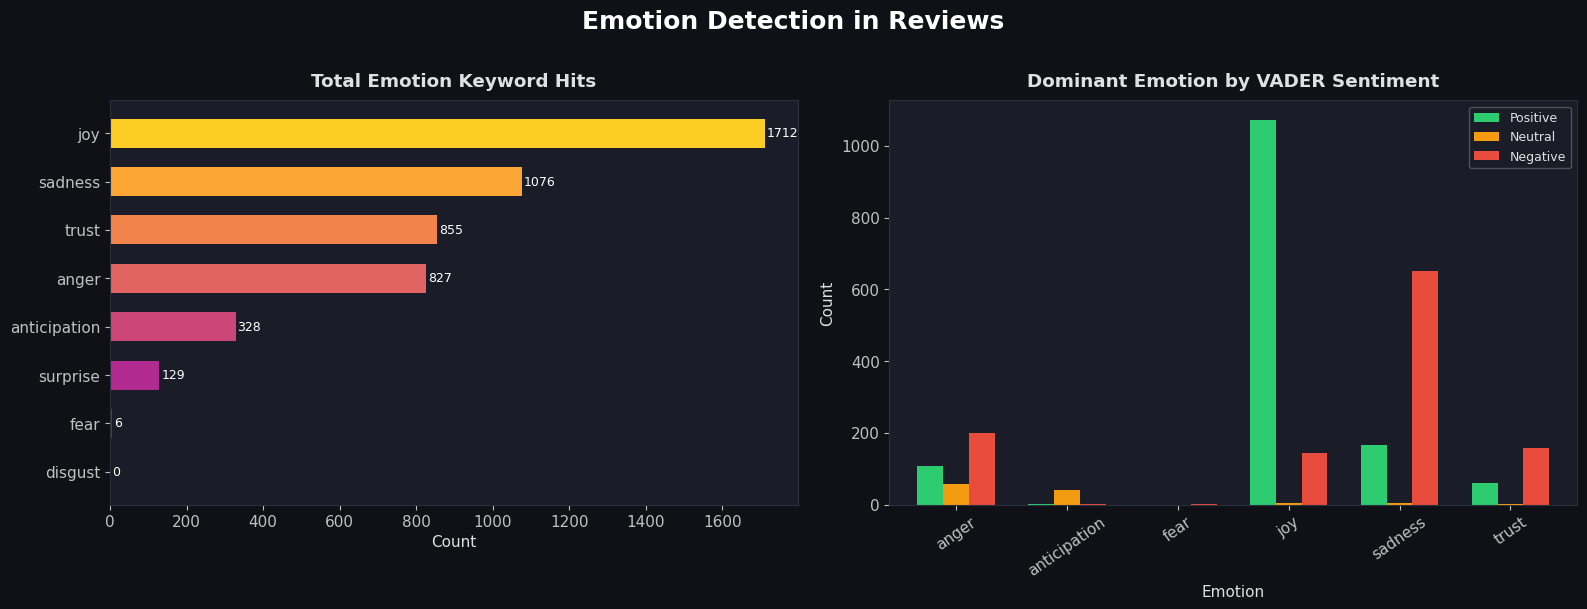

02:saved_emotion_analysis.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=DARK_BG)
fig.suptitle("Emotion Detection in Reviews", fontsize=18, fontweight="bold",
             color="white", y=1.01)

# Total emotion keyword hits
emotion_totals = reviews[list(EMOTION_LEXICON.keys())].sum().sort_values(ascending=True)
colors_emo = plt.cm.plasma(np.linspace(0.2, 0.9, len(emotion_totals)))
axes[0].barh(emotion_totals.index, emotion_totals.values,
             color=colors_emo, edgecolor="none", height=0.6)
for i, (val, name) in enumerate(zip(emotion_totals.values, emotion_totals.index)):
    axes[0].text(val + 5, i, str(int(val)), va="center", fontsize=9, color="white")
axes[0].set_title("Total Emotion Keyword Hits", fontweight="bold", pad=10)
axes[0].set_xlabel("Count")

# Dominant emotion by vader sentiment
dom_cross = pd.crosstab(reviews["vader_label"], reviews["dominant_emotion"])
dom_cross = dom_cross.drop(columns=["none"], errors="ignore")
dom_cross = dom_cross.reindex(["Positive","Neutral","Negative"]).fillna(0)
dom_cross.T.plot(kind="bar", ax=axes[1],
                 color=[PALETTE["Positive"], PALETTE["Neutral"], PALETTE["Negative"]],
                 edgecolor="none", width=0.7)
axes[1].set_title("Dominant Emotion by VADER Sentiment", fontweight="bold", pad=10)
axes[1].set_xlabel("Emotion")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend(fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "02_emotion_analysis.png"),
            dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()   
print("02:saved_emotion_analysis.png")

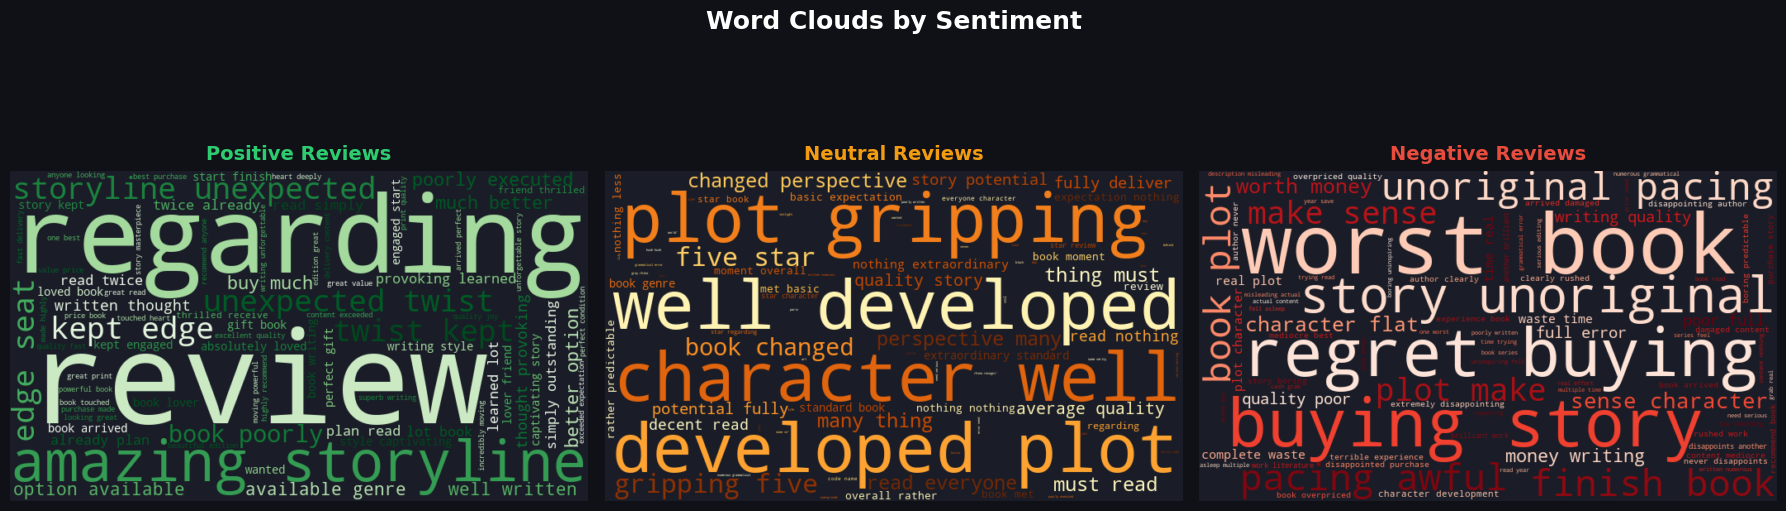

03:saved_wordclouds.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=DARK_BG)
fig.suptitle("Word Clouds by Sentiment", fontsize=18, fontweight="bold",
             color="white", y=1.01)

wc_colormaps = {"Positive": "Greens", "Neutral": "YlOrBr", "Negative": "Reds"}

for ax, (label, cmap) in zip(axes, wc_colormaps.items()):
    corpus = " ".join(reviews[reviews["vader_label"] == label]["clean_text"].dropna())
    wc = WordCloud(
        width=700, height=400,
        background_color="#1a1d27",
        colormap=cmap,
        stopwords=STOPWORDS,
        max_words=80,
        prefer_horizontal=0.85,
    ).generate(corpus if corpus.strip() else "no data")
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{label} Reviews", fontsize=14, fontweight="bold",
                 color=PALETTE[label], pad=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_wordclouds.png"),
            dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show() 
print("03:saved_wordclouds.png")

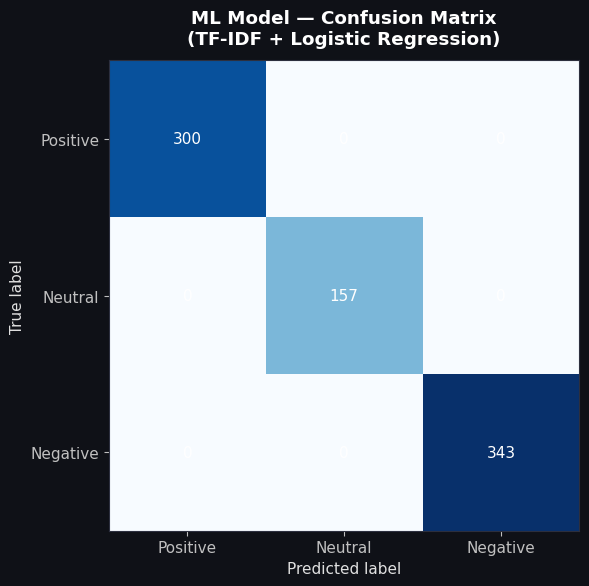

04:saved_confusion_matrix.png


In [14]:
fig, ax = plt.subplots(figsize=(7, 6), facecolor=DARK_BG)

cm = confusion_matrix(y_test, y_pred, labels=["Positive","Neutral","Negative"])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Positive","Neutral","Negative"]
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("ML Model — Confusion Matrix\n(TF-IDF + Logistic Regression)",
             fontweight="bold", pad=12, color="white")
ax.title.set_color("white")
for text in ax.texts:
    text.set_color("white")
ax.set_facecolor("#1a1d27")
fig.set_facecolor(DARK_BG)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "04_confusion_matrix.png"),
            dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()  
print("04:saved_confusion_matrix.png")

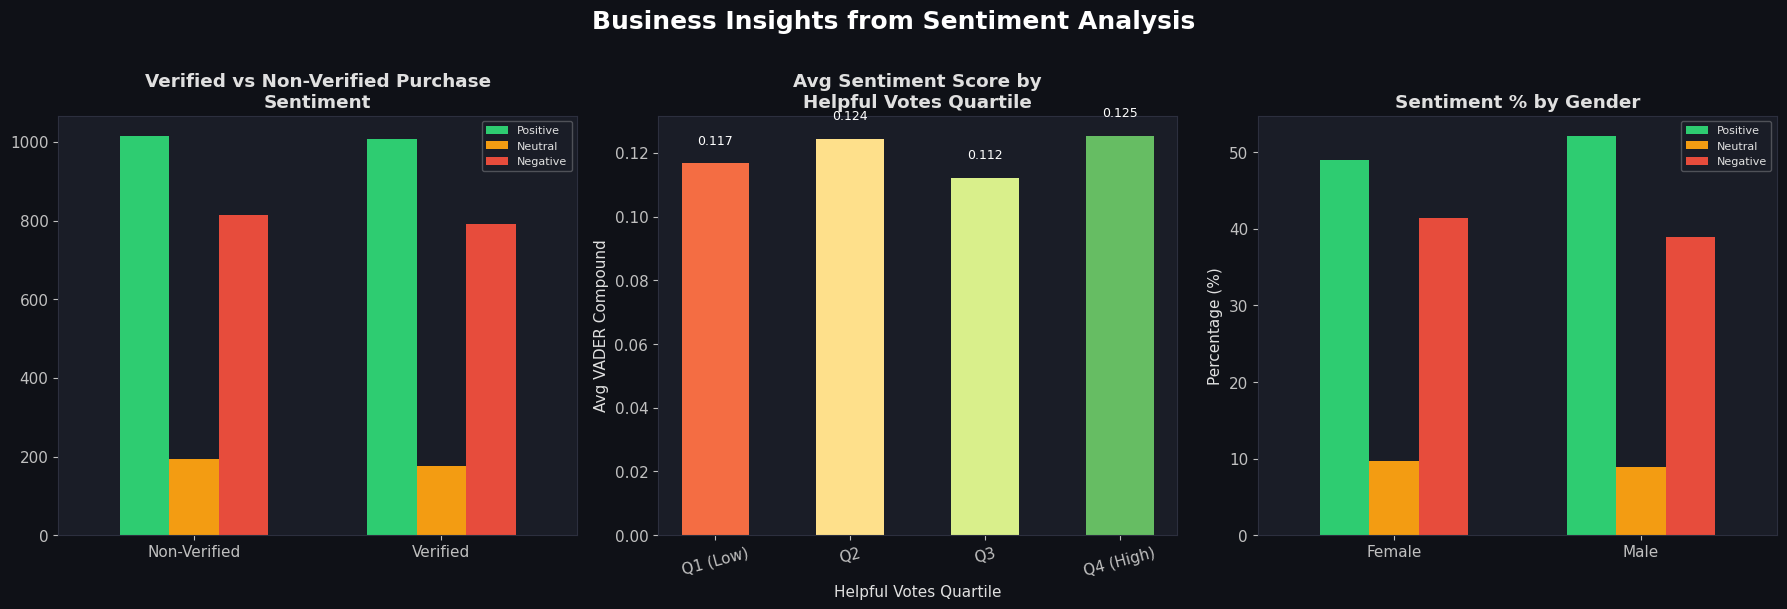

✅ 05:saved_business_insights.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=DARK_BG)
fig.suptitle("Business Insights from Sentiment Analysis", fontsize=18,
             fontweight="bold", color="white", y=1.01)

# ── (a) Verified vs Non-Verified 
vp = pd.crosstab(reviews["verified_purchase"], reviews["vader_label"])
vp = vp.reindex(columns=["Positive","Neutral","Negative"], fill_value=0)
vp.index = ["Non-Verified", "Verified"]
vp.plot(kind="bar", ax=axes[0],
        color=[PALETTE["Positive"], PALETTE["Neutral"], PALETTE["Negative"]],
        edgecolor="none", width=0.6)
axes[0].set_title("Verified vs Non-Verified Purchase\nSentiment", fontweight="bold")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(fontsize=8, framealpha=0.3)

# (b) Average sentiment by review usefulness
# We divide the Helpful Votes into 4 quartiles (Q1 being the least helpful, Q4 being the most helpful)
reviews["helpful_q"] = pd.qcut(
    reviews["helpful_votes"], q=4,
    labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"],
    duplicates="drop"
)
helpful_avg = reviews.groupby("helpful_q")["vader_compound"].mean()
bars = axes[1].bar(helpful_avg.index, helpful_avg.values, width=0.5,
                   color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(helpful_avg))),
                   edgecolor="none")
for bar, v in zip(bars, helpful_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.005,
                 f"{v:.3f}", ha="center", va="bottom", fontsize=9, color="white")
axes[1].set_title("Avg Sentiment Score by\nHelpful Votes Quartile", fontweight="bold")
axes[1].set_xlabel("Helpful Votes Quartile")
axes[1].set_ylabel("Avg VADER Compound")
axes[1].tick_params(axis="x", rotation=15)

# (c) Sentiment by gender
if "gender" in df.columns:
    gender_sent = pd.crosstab(df["gender"], df["vader_label"])
    gender_sent = gender_sent.reindex(columns=["Positive","Neutral","Negative"], fill_value=0)
    gender_pct  = gender_sent.div(gender_sent.sum(axis=1), axis=0) * 100
    gender_pct.plot(kind="bar", ax=axes[2],
                    color=[PALETTE["Positive"], PALETTE["Neutral"], PALETTE["Negative"]],
                    edgecolor="none", width=0.6)
    axes[2].set_title("Sentiment % by Gender", fontweight="bold")
    axes[2].set_xlabel("")
    axes[2].set_ylabel("Percentage (%)")
    axes[2].tick_params(axis="x", rotation=0)
    axes[2].legend(fontsize=8, framealpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05_business_insights.png"),
            dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()   
print("✅ 05:saved_business_insights.png")

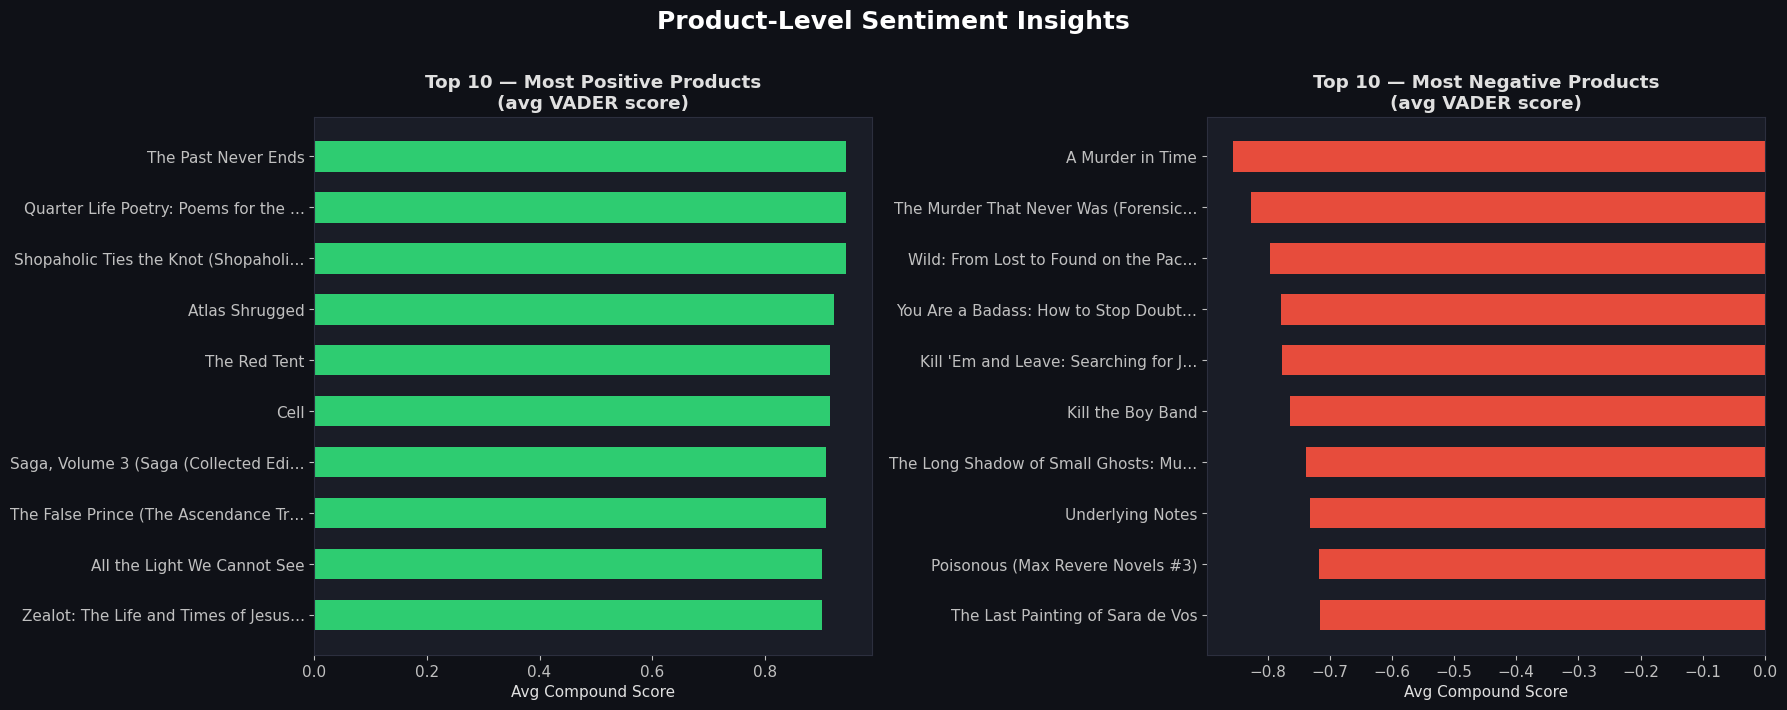

✅ 06:saved_product_sentiment.png


In [16]:
# Top 10 Positive Products
top_pos = (df[df["vader_label"] == "Positive"]
           .groupby("title")["vader_compound"].mean()
           .sort_values(ascending=False).head(10))

# The 10 worst products (most negative)
top_neg = (df[df["vader_label"] == "Negative"]
           .groupby("title")["vader_compound"].mean()
           .sort_values().head(10))

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=DARK_BG)
fig.suptitle("Product-Level Sentiment Insights", fontsize=18,
             fontweight="bold", color="white", y=1.01)

def short_title(t, n=35):
    """تختصر اسم المنتج لو طويل عشان يتناسب مع الجراف"""
    return t[:n] + "…" if len(t) > n else t

top_pos_labels = [short_title(t) for t in top_pos.index]
axes[0].barh(top_pos_labels[::-1], top_pos.values[::-1],
             color=PALETTE["Positive"], edgecolor="none", height=0.6)
axes[0].set_title("Top 10 — Most Positive Products\n(avg VADER score)", fontweight="bold")
axes[0].set_xlabel("Avg Compound Score")

top_neg_labels = [short_title(t) for t in top_neg.index]
axes[1].barh(top_neg_labels[::-1], top_neg.values[::-1],
             color=PALETTE["Negative"], edgecolor="none", height=0.6)
axes[1].set_title("Top 10 — Most Negative Products\n(avg VADER score)", fontweight="bold")
axes[1].set_xlabel("Avg Compound Score")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "06_product_sentiment.png"),
            dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()   
print("✅ 06:saved_product_sentiment.png")

In [17]:
cols_export = [
    "review_id", "product_id", "customer_id", "review_date",
    "review_text", "star_rating", "helpful_votes", "verified_purchase",
    "vader_compound", "vader_label",
    "tb_polarity", "tb_subjectivity", "tb_label",
    "star_label", "ml_label", "dominant_emotion",
] + list(EMOTION_LEXICON.keys())   

output_path = os.path.join(OUTPUT_DIR, "reviews_with_sentiment.csv")
reviews[cols_export].to_csv(output_path, index=False)

print(f" The processed data has been exported to:")
print(f"   {output_path}")
print(f"   الشكل: {reviews[cols_export].shape}")

 The processed data has been exported to:
   C:\Users\A0100\OneDrive\Desktop\sentiment analysis\outputs\reviews_with_sentiment.csv
   الشكل: (4000, 24)


In [18]:
total        = len(reviews)
vader_counts = reviews["vader_label"].value_counts()
avg_score    = reviews["vader_compound"].mean()
top_emotion  = reviews["dominant_emotion"].value_counts().idxmax()

report = f"""
╔══════════════════════════════════════════════════════╗
║       SENTIMENT ANALYSIS — SUMMARY REPORT            ║
╠══════════════════════════════════════════════════════╣
║  Total Reviews Analysed : {total:>6}                 ║ 
╠──────────────────────────────────────────────────────╣
║  VADER Sentiment Distribution:                       ║ 
║    • Positive : {vader_counts.get('Positive',0):>5} ({vader_counts.get('Positive',0)/total*100:5.1f}%)            ║
║    • Neutral  : {vader_counts.get('Neutral',0):>5} ({vader_counts.get('Neutral',0)/total*100:5.1f}%)            ║
║    • Negative : {vader_counts.get('Negative',0):>5} ({vader_counts.get('Negative',0)/total*100:5.1f}%)            ║
╠──────────────────────────────────────────────────────╣
║  Avg VADER Compound Score : {avg_score:+.4f}         ║      
║  Top Dominant Emotion     : {top_emotion:<22}        ║
╚──────────────────────────────────────────────────────╝

"""
print(report)


with open(os.path.join(OUTPUT_DIR, "summary_report.txt"), "w", encoding="utf-8") as f:
    f.write(report)




╔══════════════════════════════════════════════════════╗
║       SENTIMENT ANALYSIS — SUMMARY REPORT            ║
╠══════════════════════════════════════════════════════╣
║  Total Reviews Analysed :   4000                 ║ 
╠──────────────────────────────────────────────────────╣
║  VADER Sentiment Distribution:                       ║ 
║    • Positive :  2024 ( 50.6%)            ║
║    • Neutral  :   372 (  9.3%)            ║
║    • Negative :  1604 ( 40.1%)            ║
╠──────────────────────────────────────────────────────╣
║  Avg VADER Compound Score : +0.1196         ║      
║  Top Dominant Emotion     : none                          ║
╚──────────────────────────────────────────────────────╝


